# 

In [8]:
from ogb.utils.features import (allowable_features, atom_to_feature_vector,
 bond_to_feature_vector, atom_feature_vector_to_dict, bond_feature_vector_to_dict) 
import numpy as np
from tqdm import tqdm
import instructions_smol
import datasets
from datasets import load_dataset
import pandas as pd
import os
from rdkit import Chem
from dataset_ood_download import mol2graph, system_prompt, wrap_label
import selfies as sf
from data_utils import (
    CLASSIFICATION_BENCHMARKS,
    MOL2TEXT_BENCHMARKS,
    REGRESSION_BENCHMARKS,
    REACTION_BENCHMARKS,
    TEXT2MOL_BENCHMARKS,
)

In [9]:
mol_instruction_dataset = datasets.load_dataset(
    "zjunlp/Mol-Instructions",
    "Molecule-oriented Instructions",
    trust_remote_code=True,
)

In [10]:
mol_instruction_dataset

DatasetDict({
    description_guided_molecule_design: Dataset({
        features: ['instruction', 'input', 'output', 'metadata'],
        num_rows: 298319
    })
    forward_reaction_prediction: Dataset({
        features: ['instruction', 'input', 'output', 'metadata'],
        num_rows: 125384
    })
    molecular_description_generation: Dataset({
        features: ['instruction', 'input', 'output', 'metadata'],
        num_rows: 298319
    })
    property_prediction: Dataset({
        features: ['instruction', 'input', 'output', 'metadata'],
        num_rows: 362100
    })
    reagent_prediction: Dataset({
        features: ['instruction', 'input', 'output', 'metadata'],
        num_rows: 125384
    })
    retrosynthesis: Dataset({
        features: ['instruction', 'input', 'output', 'metadata'],
        num_rows: 129684
    })
})

In [11]:
forward_data = mol_instruction_dataset['forward_reaction_prediction']

In [12]:
def get_molinst_data_list(
        data,
        task,
        instruction_templates,
):
    list_tr_mol = []
    list_tr_label = []

    list_te_mol = []
    list_te_label = []

    from tqdm import tqdm
    iter_bar = tqdm(range(len(data)))
    for i in iter_bar:
        data_instance = data[i]
        selfies = data_instance['input']
        if task == 'reagent_prediction':
            selfies, additional_selfies = selfies.split('>>')
            smiles = sf.decoder(selfies)
            mol = Chem.MolFromSmiles(smiles)
            additional_smiles = sf.decoder(additional_selfies)
            additional_mol = Chem.MolFromSmiles(additional_smiles)
            mol = [mol, additional_mol]
        else:
            smiles = sf.decoder(selfies)
            mol = Chem.MolFromSmiles(smiles)
        label = data_instance['output']

        if "train" in data_instance['metadata']:
            list_tr_label.append(label)
            list_tr_mol.append(mol)
        elif "test" in data_instance['metadata']:
            list_te_label.append(label)
            list_te_mol.append(mol)
        elif "val" in data_instance['metadata']:
            pass
        else:
            print(data_instance)
            raise ValueError

    list_tr_data = get_data_list(
        list_mol=list_tr_mol,
        list_label=list_tr_label,
        task=task,
        instruction_templates=instruction_templates,
    )
    list_te_data = get_data_list(
        list_mol=list_te_mol,
        list_label=list_te_label,
        task=task,
        instruction_templates=instruction_templates,
    )
    print(len(list_tr_data), len(list_te_data))
    return list_tr_data, list_te_data

def prepare_data_instance(
    mol,
    label,
    task,
    instruction_templates,
    system_prompt,
    mol_token="<mol>",
    num_query_tokens=32,
    list_reject_mol=None,
    num_reject=-1,
):

    label = wrap_label(label, task=task)
    input_prompt = np.random.choice(instruction_templates).item()
    assert "<INPUT>" in input_prompt, f"llm_prompt should contain <INPUT>"
    graph_sequence = "<GRAPH>" + mol_token * num_query_tokens + "</GRAPH>"

    if "reagent_prediction" in task:
        smiles = Chem.MolToSmiles(mol[0]).replace("->", "").replace("<-", "")
        selfies = sf.encoder(smiles)
        input_mol_string = "<SELFIES> " + selfies + " </SELFIES>"
        input_mol_string_graph = input_mol_string + graph_sequence

        additional_smiles = Chem.MolToSmiles(mol[1])
        additional_selfies = sf.encoder(additional_smiles)
        additional_input_mol_string = "<SELFIES> " + additional_selfies + " </SELFIES>"
        additional_input_mol_string_graph = additional_input_mol_string + graph_sequence

        input_mol_string = input_mol_string + "|>>|" + additional_input_mol_string
        input_information = (
            input_mol_string_graph + "|>>|" + additional_input_mol_string_graph
        )

        graph = mol2graph(mol[0])
        additional_graph = mol2graph(mol[1])
    elif task in TEXT2MOL_BENCHMARKS:
        assert isinstance(
            mol, str
        ), f"mol should be a text description, but got {type(mol)}"
        input_information = "<DESCRIPTION> " + mol + " </DESCRIPTION>"
        input_mol_string = mol

        graph = mol2graph(Chem.MolFromSmiles("CCC"))  # null graph
        additional_graph = graph

    else:
        assert isinstance(
            mol, Chem.Mol
        ), f"mol should be a RDKit Mol object, but got {type(mol)}"
        mol = mol
        smiles = Chem.MolToSmiles(mol).replace("->", "").replace("<-", "")
        selfies = sf.encoder(smiles)
        input_mol_string = "<SELFIES> " + selfies + " </SELFIES>"
        input_information = input_mol_string + graph_sequence

        graph = mol2graph(mol)
        additional_graph = graph

    input_prompt = input_prompt.replace("<INPUT>", input_information)

    formatted_prompt_text = (
        "<s>[INST] " + system_prompt + " \n\n" + input_prompt + " [/INST] "
    )
    formatted_target_text = label + " </s>"

    data = {
        "task": task,
        "x": graph["node_feat"],
        "edge_index": graph["edge_index"],
        "edge_attr": graph["edge_feat"],
        "additional_x": additional_graph["node_feat"],
        "additional_edge_index": additional_graph["edge_index"],
        "additional_edge_attr": additional_graph["edge_feat"],
        "input_mol_string": input_mol_string,
        "prompt_text": formatted_prompt_text,
        "target_text": formatted_target_text,
    }
    if list_reject_mol is not None:
        for i in range(len(list_reject_mol)):
            reject_mol = list_reject_mol[i]
            if num_reject > 0 and len(list_reject_mol) < num_reject:
                reject_mol = list_reject_mol[i % len(list_reject_mol)]
            graph = mol2graph(reject_mol)
            additional_graph = graph
            data.update(
                {
                    f"{i}-th_rejected_x": graph["node_feat"],
                    f"{i}-th_rejected_edge_index": graph["edge_index"],
                    f"{i}-th_rejected_edge_attr": graph["edge_feat"],
                    f"{i}-th_additional_rejected_x": additional_graph["node_feat"],
                    f"{i}-th_additional_rejected_edge_index": additional_graph[
                        "edge_index"
                    ],
                    f"{i}-th_additional_rejected_edge_attr": additional_graph[
                        "edge_feat"
                    ],
                }
            )
    return data


def get_data_list(
    list_mol,
    list_label,
    task,
    instruction_templates,
    list_reject_mol=None,
    num_reject=-1,
):
    list_data = []
    iter_bar = tqdm(range(len(list_mol)))

    for i in iter_bar:
        data = prepare_data_instance(
            mol=list_mol[i],
            label=list_label[i],
            task=task,
            instruction_templates=instruction_templates,
            system_prompt=system_prompt,
            list_reject_mol=list_reject_mol,
            num_reject=num_reject,
        )
        list_data.append(data)
    return list_data

In [13]:
list_forward_train_data, list_forward_test_data = get_molinst_data_list(
    data=forward_data,
    instruction_templates=instructions_smol.forward_reaction_prediction,
    task="forward_reaction_prediction",
)

  0%|          | 0/125384 [00:00<?, ?it/s][08:28:18] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
  0%|          | 89/125384 [00:00<02:20, 888.98it/s][08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighbors
[08:28:19] WARNING: not removing hydrogen atom without neighb

124384 1000


In [35]:
data_instance = list_forward_train_data[0]
data_instance.keys()

dict_keys(['task', 'x', 'edge_index', 'edge_attr', 'additional_x', 'additional_edge_index', 'additional_edge_attr', 'input_mol_string', 'prompt_text', 'target_text'])

In [26]:
input_mol_string = data_instance['input_mol_string']
selfies = input_mol_string.replace("<SELFIES> ", "").replace(" </SELFIES>", "")
smiles = sf.decoder(selfies)
smiles


'C1CCOC1.Cl.O=CC2=CC([N+1](=O)[O-1])=C(F)C=C2F.[BH4-1].[Na+1]'

In [ ]:
def devide_mols(data_instance):
    input_mol_string = data_instance['input_mol_string']
    selfies = input_mol_string.replace("<SELFIES> ", "").replace(" </SELFIES>", "")
    smiles = sf.decoder(selfies)
    mol = Chem.MolFromSmiles(smiles)

    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)

    #graphs = {}
    list_graphs = []
    for i, frag in enumerate(frags):
        graph = mol2graph(frag)
    #graphs.update({f"{i}-th_graph": graph})
        list_graphs.append(graph)
    return list_graphs

import multiprocessing as mp
def process_data_parallel(data_instances, num_workers=4):
    with mp.Pool(num_workers) as pool:
        results = list(tqdm(pool.imap(devide_mols, data_instances), total=len(data_instances)))
    return results


# Number of worker processes (set to match your CPU core count)
num_workers = 20  # Or set explicitly, e.g., num_workers=4

# Process the data in parallel
list_total_graphs = process_data_parallel(list_forward_train_data, num_workers=num_workers)

"""list_total_graphs = []
iter_bar = tqdm(range(len(list_forward_train_data)))
for i in iter_bar:
    data_instance = list_forward_train_data[i]
    graphs = devide_mols(data_instance)
    list_total_graphs.append(graphs)"""

  0%|          | 88/124384 [00:00<11:20, 182.58it/s][09:24:13] WARNING: not removing hydrogen atom without neighbors
[09:24:13] WARNING: not removing hydrogen atom without neighbors
[09:24:13] WARNING: not removing hydrogen atom without neighbors
  0%|          | 107/124384 [00:00<12:49, 161.52it/s][09:24:13] WARNING: not removing hydrogen atom without neighbors
[09:24:13] WARNING: not removing hydrogen atom without neighbors
  0%|          | 124/124384 [00:00<13:05, 158.13it/s][09:24:13] WARNING: not removing hydrogen atom without neighbors
[09:24:14] WARNING: not removing hydrogen atom without neighbors
[09:24:13] WARNING: not removing hydrogen atom without neighbors
[09:24:13] WARNING: not removing hydrogen atom without neighbors
  0%|          | 140/124384 [00:00<15:04, 137.37it/s][09:24:14] WARNING: not removing hydrogen atom without neighbors
[09:24:14] WARNING: not removing hydrogen atom without neighbors
[09:24:14] WARNING: not removing hydrogen atom without neighbors
[09:24:14

In [38]:
graphs

{'0-th_graph': {'edge_index': array([[0, 1, 1, 2, 2, 3, 3, 4, 4, 0],
         [1, 0, 2, 1, 3, 2, 4, 3, 0, 4]]),
  'edge_feat': array([[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]),
  'node_feat': array([[5, 0, 4, 5, 2, 0, 2, 0, 1],
         [5, 0, 4, 5, 2, 0, 2, 0, 1],
         [5, 0, 4, 5, 2, 0, 2, 0, 1],
         [7, 0, 2, 5, 0, 0, 2, 0, 1],
         [5, 0, 4, 5, 2, 0, 2, 0, 1]]),
  'num_nodes': 5},
 '1-th_graph': {'edge_index': array([], shape=(2, 0), dtype=int64),
  'edge_feat': array([], shape=(0, 3), dtype=int64),
  'node_feat': array([[16,  0,  1,  5,  1,  0,  2,  0,  0]]),
  'num_nodes': 1},
 '2-th_graph': {'edge_index': array([[ 0,  1,  1,  2,  2,  3,  3,  4,  4,  5,  5,  6,  5,  7,  4,  8,
           8,  9,  8, 10, 10, 11, 11, 12, 11,  2],
         [ 1,  0,  2,  1,  3,  2,  4,  3,  5,  4,  6,  5,  7,  5,  8,  4,
           9,  8, 10

In [32]:
mol2graph(frags[0])

{'edge_index': array([[0, 1, 1, 2, 2, 3, 3, 4, 4, 0],
        [1, 0, 2, 1, 3, 2, 4, 3, 0, 4]]),
 'edge_feat': array([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]),
 'node_feat': array([[5, 0, 4, 5, 2, 0, 2, 0, 1],
        [5, 0, 4, 5, 2, 0, 2, 0, 1],
        [5, 0, 4, 5, 2, 0, 2, 0, 1],
        [7, 0, 2, 5, 0, 0, 2, 0, 1],
        [5, 0, 4, 5, 2, 0, 2, 0, 1]]),
 'num_nodes': 5}

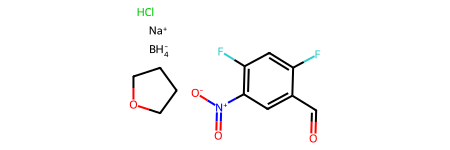

In [31]:
mol

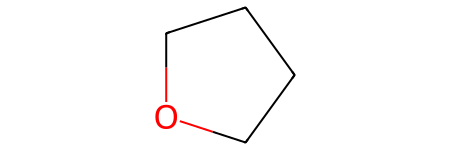

In [28]:
frags[0]

In [15]:
retro_data = mol_instruction_dataset['retrosynthesis']
list_retro_train_data, list_retro_test_data = get_molinst_data_list(
    data=retro_data,
    instruction_templates=instructions_smol.retrosynthesis,
    task="retrosynthesis",
)

100%|██████████| 1000/1000 [00:01<00:00, 780.06it/s]

128684 1000


In [16]:
reagent_data = mol_instruction_dataset['reagent_prediction']
list_reagent_train_data, list_reagent_test_data = get_molinst_data_list(
    data=reagent_data,
    instruction_templates=instructions_smol.reagent_prediction,
    task="reagent_prediction",
)

100%|██████████| 1000/1000 [00:02<00:00, 386.29it/s]

124384 1000


In [17]:
data_dict = {
    "task": "forward_reaction_prediction",
    "train": list_forward_train_data,
    "test": list_forward_test_data
}


for split in ["train", "test"]:
    list_data = data_dict[split]
    task = data_dict["task"]
    
    dataset = datasets.Dataset.from_list(list_data)
    dataset.save_to_disk(
        f"/data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_{split}_{task}_0219"
    )

Saving the dataset (1/1 shards): 100%|██████████| 1000/1000 [00:00<00:00, 48870.99 examples/s]


In [18]:
list_forward_train_data[0]

{'task': 'forward_reaction_prediction',
 'x': array([[ 7,  0,  1,  5,  0,  0,  1,  0,  0],
        [ 5,  0,  3,  5,  1,  0,  1,  0,  0],
        [ 5,  0,  3,  5,  0,  0,  1,  1,  1],
        [ 5,  0,  3,  5,  1,  0,  1,  1,  1],
        [ 5,  0,  3,  5,  0,  0,  1,  1,  1],
        [ 6,  0,  3,  6,  0,  0,  1,  0,  0],
        [ 7,  0,  1,  5,  0,  0,  1,  0,  0],
        [ 7,  0,  1,  4,  0,  0,  1,  0,  0],
        [ 5,  0,  3,  5,  0,  0,  1,  1,  1],
        [ 8,  0,  1,  5,  0,  0,  2,  0,  0],
        [ 5,  0,  3,  5,  1,  0,  1,  1,  1],
        [ 5,  0,  3,  5,  0,  0,  1,  1,  1],
        [ 8,  0,  1,  5,  0,  0,  2,  0,  0],
        [ 5,  0,  4,  5,  2,  0,  2,  0,  1],
        [ 5,  0,  4,  5,  2,  0,  2,  0,  1],
        [ 5,  0,  4,  5,  2,  0,  2,  0,  1],
        [ 7,  0,  2,  5,  0,  0,  2,  0,  1],
        [ 5,  0,  4,  5,  2,  0,  2,  0,  1],
        [16,  0,  1,  5,  1,  0,  2,  0,  0],
        [ 4,  0,  4,  4,  4,  0,  2,  0,  0],
        [10,  0,  0,  6,  0,  0,  5

In [19]:
data_dict = {
    "task": "retrosynthesis",
    "train": list_retro_train_data,
    "test": list_retro_test_data
}


for split in ["train", "test"]:
    list_data = data_dict[split]
    task = data_dict["task"]
    
    dataset = datasets.Dataset.from_list(list_data)
    dataset.save_to_disk(
        f"/data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_{split}_{task}_0219"
    )

Saving the dataset (1/1 shards): 100%|██████████| 1000/1000 [00:00<00:00, 69832.91 examples/s]


In [20]:
data_dict = {
    "task": "reagent_prediction",
    "train": list_reagent_train_data,
    "test": list_reagent_test_data
}


for split in ["train", "test"]:
    list_data = data_dict[split]
    task = data_dict["task"]
    
    dataset = datasets.Dataset.from_list(list_data)
    dataset.save_to_disk(
        f"/data/data/Mol-LLM-v7.1/mistralai-Mistral-7B-Instruct-v0.3_string+graph_q32_{split}_{task}_0219"
    )

Saving the dataset (1/1 shards): 100%|██████████| 1000/1000 [00:00<00:00, 62966.19 examples/s]
